This is the main file for Dennis Mitzeus' bachelor thesis project. The project includes data preprocessing, project structuring, technical implementation, and evaluation.

The current Architecture looks like this:

<img width="400px" src="./figures/artifact_flowchart_new.png"></img>

## Structure

This project will go through

1. Data Preprocessing
2. API setup
3. Technical Implementation
4. Evaluation

## Project

In [1]:
# Fixes need to restart kernel everytime I update components in separate files
%load_ext autoreload
%autoreload 2

# Import Declarations
from IPython.display import Markdown, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns
import re
import requests
import tarfile
import os
import shutil

In [2]:
TOTAL_SIZE = 100 # Total size of each flashcard set
BATCH_SIZE = 20 # How many words get introduced at a time eg. 20: ask LLM with 20 flashcards, then again with 40, then 60,..., until total size reached
MODEL_SAMPLE_SIZE = 10 # How many times to ask the same question (to get a distribution of probabilistic results)

### Data Preprocessing

#### Status for language Datasets Found:
* ✅ Swedish: Kelly (https://spraakbanken.gu.se/resurser/kelly)
* ✅ Spanish: ChatSubs (https://linkinghub.elsevier.com/retrieve/pii/S2352340923006650) (Data link: https://github.com/conversa-ai/ChatSubs)
* ✅ Korean: 한국어 학습용 어휘 목록(엑셀 파일) (TOPIK, from National Institute of Korean Language) (https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)

#### Dataset explanations

##### Swedish

The Swedish dataset "Kelly" is used for Swedish. Swedish dataset contains 9 columns: "ID", "Raw freq", "WPM" "CEFR levels", "Source", "Grammar", "Swedish items for translation", "Word classes", and "Examples". 

Raw freq corresponds to the total frequency over the whole extracted corpus, WPM corresponds to a ratio of how many words per 1 000 000 words is this word, CEFR levels correspond to how advanced a word is following the Common European Framework of Reference for Languages, Source is from which corpus the word comes from, Grammar corresponds to certain prefixes or suffixes some word classes inherit (for example "att" before all root verbs), Swedish items for translation is the word itself, word classes correspond to which grammatical type a word is (more details under "Lookup" workspace in file datasets/1-raw/swedish.xls), lastly, examples provide example sentences of use for some words.

##### Spanish

\# TODO fill this in

##### Korean

Korean dataset is from the National Korean Language Institute which is a put together list of the most common words in the Korean language for foreign learners practicing for the TOPIK (Test of Proficiency in Korean) test. Korean dataset contains 5 columns: "순위", "단어", "품사", "풀이", and "등급".

순위 corresponds to the frequency ranking based on a 2002 researcher report named "Survey on Modern Korean Usage Frequency", 단어 corresponds to the word itself, 품사 refers to the grammatical type a word is (more details can be found at [the official dataset site](https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)),풀이 refers to the Hanja (漢字) versions of some words, and 등급 refers to which TOPIK level a word is in where A means basic B is intermediate and C is advanced level.

### Preprocessing based on some criteria

For our preprocessing we need to fulfill some critera to get a good subset of the datasets viable for testing in the thesis architecture. 

It requires:

1. Vocabulary list of 100 Words per Language
2. A varied set of grammar types (Nouns, Verbs etc.), some weight more than others such as verbs being more important than conjunctions for basic language.
3. The words should be the most common in most cases. This means relative frequency is better than raw frequency.

#### Batches

Batches are subsets of a final dataset for gradual introduction into the thesis architecture system and works similar to smaller independent datasets inside the bigger one, meaning each batch will have similar word type ratios and not purely based on commonality (in case of a vocabulary list of 100 words, most adjectives may be top 60 meaning no adjectives can ever be used until batches after top 60 gets introduced)

This is a visual image of batches: 

<img src="./figures/flashcard_batches.png" width="400px"></img>

### Preprocessing

#### Swedish

In [ ]:
# removing NaN's
swedish_raw = pd.read_csv("data/2-extracted/swedish.csv", sep=";") # import

# drop rows with NaN's for all necessary features
swedish_dropped_nas = swedish_raw.dropna(axis=0, subset=["WPM", "CEFR levels", "Swedish items for translation", "Word classes"])

table_stats_dropped = pd.DataFrame(columns=["Nr of NaN Before", "Nr of NaN After"])

table_stats_dropped["Nr of NaN Before"] = swedish_raw.isna().sum().to_list()
table_stats_dropped["Nr of NaN After"] = swedish_dropped_nas.isna().sum().to_list()
table_stats_dropped.index = swedish_dropped_nas.columns

display(table_stats_dropped)

print(f"Total Nr of Entries Before: {len(swedish_raw)}")
print(f"Total Nr of Entries After: {len(swedish_dropped_nas)}")

,Nr of NaN Before,Nr of NaN After
ID,0,0
Raw freq,2650,2650
WPM,0,0
CEFR levels,0,0
Source,0,0
Grammar,2841,2841
Swedish items for translation,0,0
Word classes,0,0
Examples,8180,8180


Total Nr of Entries Before: 8425
Total Nr of Entries After: 8425


In [4]:
# changing WPM to numeric
swedish_dropped_nas["WPM"] = swedish_dropped_nas["WPM"].str.replace(",", ".").astype("Float64")

# drop rows with super high WPM values (outliers)
swedish_dropped_nas = swedish_dropped_nas[swedish_dropped_nas["WPM"] < 1000000]

In [5]:
# Removing unnecessary word classes and clumping similar word classes together

swedish_dropped_nas["Word classes"].unique() # finding all unique word classes

# exclude unnecessary word classes
unnecessary_word_classes = ["numeral", "proper name", "particip"]

swedish_word_classes_excluded = swedish_dropped_nas[~swedish_dropped_nas["Word classes"].isin(unnecessary_word_classes)]

# clump similar word classes together, (e.g. all nouns together, verbs together etc.)
clump_word_classes = {
    "noun": ["noun", "noun-en", "noun-ett", "noun-en/-ett"],
    "verb": ["verb", "aux verb"]
}

word_types = swedish_word_classes_excluded["Word classes"]

for word_type, word_class_list in clump_word_classes.items(): # clumping word classes together
    word_types = word_types.replace(word_class_list, word_type)

swedish_clumped = swedish_word_classes_excluded.copy()
swedish_clumped["Word classes"] = word_types

# remove extra info from word itself
swedish_clumped["Swedish items for translation"] = swedish_clumped[
    "Swedish items for translation"
].str.replace(r"\s*\([^)]*\)", "", regex=True)

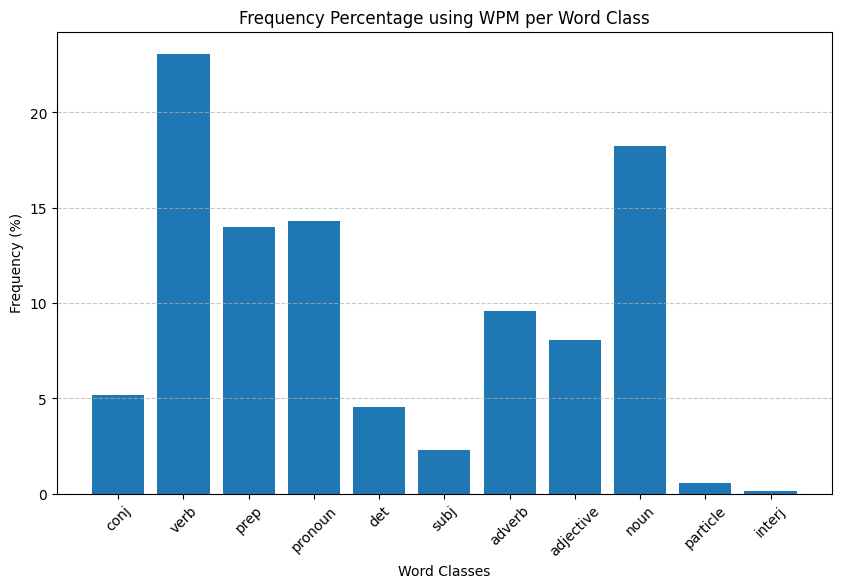

In [6]:
# Figuring out frequency of each word class using WPM 

# calculate the sum of all WPM and for each to get weighted percentages
total_wpm = swedish_clumped["WPM"].sum()

percentages = []

for word_type in swedish_clumped["Word classes"].unique():

    word_type_wpm = swedish_clumped[swedish_clumped["Word classes"] == word_type]["WPM"].sum()

    percentage = (word_type_wpm / total_wpm) * 100
    percentages.append(percentage)


plt.figure(figsize=(10, 6))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.bar(swedish_clumped["Word classes"].unique(), percentages)
# plt.figsize = (10, 6)
plt.xlabel("Word Classes")
plt.ylabel("Frequency (%)")
plt.title("Frequency Percentage using WPM per Word Class")
plt.xticks(rotation=45)
plt.show()

In [7]:
# Calculate discrete amounts based on percentages (where each category gets at least 1 entry)

divisor = TOTAL_SIZE - len(swedish_clumped["Word classes"].unique()) 

discrete_list = []

percentages = np.array(percentages)
discrete_list = np.floor(((percentages / 100) * divisor) + 1) # gets the floored version of amounts
fractional_parts = ((percentages / 100) * divisor) + 1 - discrete_list # saves unused fractions that was removed with flooring

leftover_amount = int(TOTAL_SIZE - discrete_list.sum()) # how many entries left to distribute

# distributing leftovers based on floored fractions
fractional_parts = pd.Series(fractional_parts, index=swedish_clumped["Word classes"].unique()).sort_values(ascending=False) # link it to word classes

discrete_amounts = pd.Series(discrete_list, index=swedish_clumped["Word classes"].unique(), dtype=int)


for i in range(leftover_amount):
    discrete_amounts.loc[fractional_parts.index[i]] += 1 # distributes last leftovers to top fractions according to 

print(f"Percentages converted to discrete amounts (with at least 1 entry for each category): {discrete_amounts.sum()}/{TOTAL_SIZE}")
display(discrete_amounts) # making sure there's at least 1 entry for each category and showing amounts

# divide into batches for dataset assembly

Percentages converted to discrete amounts (with at least 1 entry for each category): 100/100


conj          6
verb         22
prep         13
pronoun      14
det           5
subj          3
adverb       10
adjective     8
noun         17
particle      1
interj        1
dtype: int64

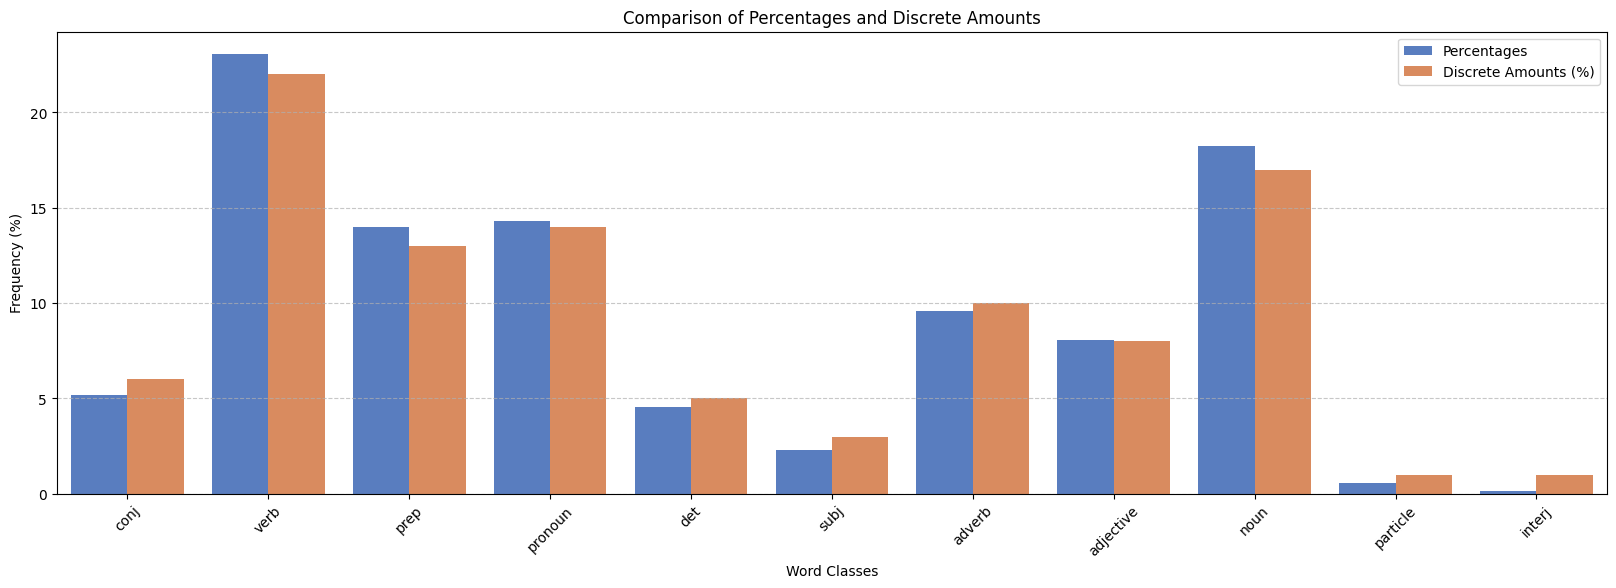

In [8]:
# Plot differences of discrete amounts and percentages for visualization of distribution

df_plot = pd.concat(
    [
        pd.DataFrame(
            {
                "Word Classes": swedish_clumped["Word classes"].unique(),
                "Frequency (%)": percentages,
                "Type": ["Percentages"] * len(percentages),
            }
        ),
        pd.DataFrame(
            {
                "Word Classes": discrete_amounts.index,
                "Frequency (%)": (discrete_amounts / TOTAL_SIZE) * 100,
                "Type": ["Discrete Amounts (%)"] * len(discrete_amounts),
            }
        ),
    ],
    ignore_index=True,
)

plt.figure(figsize=(20, 6))
plt.grid(axis="y", linestyle="--", alpha=0.7)
sns.barplot(
    x="Word Classes",
    y="Frequency (%)",
    hue="Type",
    data=df_plot,
    palette="muted",
)

plt.xlabel("Word Classes")
plt.ylabel("Frequency (%)")
plt.title("Comparison of Percentages and Discrete Amounts")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [9]:
# pick out top words for each category and make a class for each flashcard set with batches and total as attributes
word_list = swedish_clumped

# pick from `word_list` according to `discrete_amounts`

candidate_indexes = []

for word_class in swedish_clumped["Word classes"].unique():
    classwise_subset = word_list[word_list["Word classes"] == word_class]
    classwise_subset = classwise_subset.sort_values(by="WPM", ascending=False) # sort to get top words
    candidate_indexes.append(classwise_subset.head(discrete_amounts.loc[word_class]).index)
    print(f"Added {word_class} with {discrete_amounts.loc[word_class]} entries.")


candidate_indexes = np.concatenate(candidate_indexes)


Added conj with 6 entries.
Added verb with 22 entries.
Added prep with 13 entries.
Added pronoun with 14 entries.
Added det with 5 entries.
Added subj with 3 entries.
Added adverb with 10 entries.
Added adjective with 8 entries.
Added noun with 17 entries.
Added particle with 1 entries.
Added interj with 1 entries.


In [10]:
# Building final dataset
final_dataset = word_list.loc[candidate_indexes]

final_dataset["Word classes"].value_counts()

Word classes
verb         22
noun         17
pronoun      14
prep         13
adverb       10
adjective     8
conj          6
det           5
subj          3
particle      1
interj        1
Name: count, dtype: int64

In [ ]:
final_dataset.to_csv(f"data/3-final/swedish{TOTAL_SIZE}.csv", index=False)

final_dataset

,ID,Raw freq,WPM,CEFR levels,Source,Grammar,Swedish items for translation,Word classes,Examples
86,87,2966316.0,26019.68,A1,SweWaC,NaN,och,conj,NaN
112,113,518253.0,4545.97,A1,SweWaC,NaN,men,conj,NaN
117,118,428910.0,3762.28,A1,SweWaC,NaN,som,conj,NaN
125,126,357846.0,3138.92,A1,SweWaC,NaN,eller,conj,NaN
164,165,162897.0,1428.89,A1,SweWaC,NaN,än,conj,NaN
...,...,...,...,...,...,...,...,...,...
238,239,70441.0,617.89,A1,SweWaC,en,värld,noun,NaN
242,243,69197.0,606.98,A1,SweWaC,ett,folk,noun,NaN
243,244,68786.0,603.37,A1,SweWaC,en,regering,noun,NaN
169,170,150755.0,1322.38,A1,SweWaC,NaN,upp,particle,NaN


#### Spanish

In [ ]:
# # Dataset does not fit locally so download from source


# def safe_filter(tarinfo, extract_path):
#     # Reject absolute paths or parent directory traversal
#     if os.path.isabs(tarinfo.name) or ".." in tarinfo.name:
#         return None
#     return tarinfo  # keep original folder structure


# spanish_url = "https://zenodo.org/records/8220853/files/ChatSubs.tar.gz?download=1"
# spanish_filename = "ChatSubs.tar.gz"

# print("Downloading Spanish dataset...")
# response = requests.get(spanish_url, stream=True)
# response.raise_for_status()  # Check if the download was successful

# with open(os.path.join("data/1-raw/spanish", spanish_filename), "wb") as f:
#     for chunk in response.iter_content(chunk_size=8192):
#         f.write(chunk)

# print("Download completed. Extracting files...")
# with tarfile.open(os.path.join("data/1-raw/spanish", spanish_filename), "r:gz") as tar:
#     tar.extractall(path="data/1-raw/spanish/", filter=safe_filter)

# print("Extraction completed. Cleaning up...")
# os.remove(os.path.join("data/1-raw/spanish", spanish_filename))
# for item in os.listdir("data/1-raw/spanish/open_subtitles_es"):
#     shutil.move(os.path.join("data/1-raw/spanish/open_subtitles_es", item), os.path.join("data/1-raw/spanish", item))
# shutil.rmtree("data/1-raw/spanish/open_subtitles_es")
# shutil.rmtree("data/1-raw/spanish/open_subtitles_ca")
# shutil.rmtree("data/1-raw/spanish/open_subtitles_eu")
# shutil.rmtree("data/1-raw/spanish/open_subtitles_gl")
# print("Spanish dataset downloaded and extracted successfully.")

Download completed. Extracting files...
Extraction completed. Cleaning up...
Spanish dataset downloaded and extracted successfully.


In [2]:
from src.preprocessing.spanish import load_dataset as load_spanish_dataset

load_spanish_dataset()

Download completed. Extracting files...
Extraction completed. Cleaning up...
Spanish dataset downloaded and extracted successfully.


#### Korean

In [12]:
# TODO Korean

### API Setup

In [14]:
# imports
from openai import OpenAI
from dotenv import load_dotenv, dotenv_values
import os
import json

from model.models import Conversation_Model, Conversation
from model.prompts import REVISED_PROMPT_STRING as SYSTEM_PROMPT_STRING

In [15]:
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_KEY"))

### Technical Implementation

Technical implementation involves prompting, model design, flashcard imports, batch managements and running to gather data about the performance of measurable components of the system.

In this case testing to ask about different components of the swedish language and see how it performs.

In [ ]:
# importing data
swedish_vocab = pd.read_csv("data/3-final/swedish100.csv")

# Preprocess into standard format for flashcards

# drop unnecessary columns & rename
swedish_vocab.drop(columns=["ID", "Raw freq", "Source", "Examples"], inplace=True)
swedish_vocab.rename(columns={
    "WPM": "freq",
    "Grammar": "affix",
    "CEFR levels": "level",
    "Swedish items for translation": "word",
    "Word classes": "grammar_type"
}, inplace=True)

swedish_vocab.head(100)

,freq,level,affix,word,grammar_type
0,26019.68,A1,NaN,och,conj
1,4545.97,A1,NaN,men,conj
2,3762.28,A1,NaN,som,conj
3,3138.92,A1,NaN,eller,conj
4,1428.89,A1,NaN,än,conj
...,...,...,...,...,...
95,617.89,A1,en,värld,noun
96,606.98,A1,ett,folk,noun
97,603.37,A1,en,regering,noun
98,1322.38,A1,NaN,upp,particle


In [17]:
test_questions_swedish = [ # Make some test questions
    "What's the difference between 'en' and 'ett' in swedish?",
    # "When do you use 'är' vs 'har' in swedish?",
    # "Why do you say 'jag heter' instead of 'jag är' in swedish?",
    # "What does 'lagom' mean in swedish?",
    # "How do I know if a word is a 'ett' or 'en' word in swedish?",
]

conversation = ""

conversation_data = []

# test_questions_swedish = ["Hello"]

print(f"""
Current Setup:
    Total Nr. Questions: {len(test_questions_swedish)}

    Flashcard Set Size:  {TOTAL_SIZE}
    Batch Size:          {BATCH_SIZE}
    Total Nr. Batches:   {TOTAL_SIZE // BATCH_SIZE}

    Total Nr. Samples:   {MODEL_SAMPLE_SIZE}
""")

total_runs = (TOTAL_SIZE // BATCH_SIZE) * len(test_questions_swedish) * MODEL_SAMPLE_SIZE

print(f"A total of {total_runs} conversations will be generated.")

run_counter = 0
for question_i, question in enumerate(test_questions_swedish):
    # for batch_i in range(1):
    for batch_i in range(TOTAL_SIZE // BATCH_SIZE):
        for sample_i in range(MODEL_SAMPLE_SIZE):
            run_counter += 1

            vocab_subset = swedish_vocab[: (batch_i + 1) * BATCH_SIZE]

            conversation = Conversation_Model(
                SYSTEM_PROMPT_STRING,
                model_client=client,
                model_name="gpt-5.2",
                keep_history=True,
                save_history_to_file=False,
            )

            # add flashcard limits
            conversation.import_word_library(vocab_subset)

            prompt = question
            response = conversation.ask(prompt)
            print(
                f"{run_counter}/{total_runs}: Sample {sample_i + 1} of question nr {question_i + 1} using {(batch_i + 1) * BATCH_SIZE} words Generated."
            )
            # print(f"You: {question}")
            # print(f"Model: {response}")
            # print("\n")

            # save conversation for from testing questions

            # into conversation data
            # conversation_data.append(
            #     {
            #         "id": f"{batch_i + 1}" + f"{(batch_i + 1) * BATCH_SIZE}",
            #         "question_id": question_i + 1,
            #         "nr_vocab": (batch_i + 1) * BATCH_SIZE,
            #         "question": question,
            #         "response": response,
            #         "word_limits": conversation.flashcards
            #     }
            # )
            conversation_data.append(
                Conversation(
                    id=f"{batch_i + 1}" + f"{(batch_i + 1) * BATCH_SIZE}" + f"{sample_i + 1}",
                    question_id=question_i,
                    sample_id=sample_i,
                    nr_vocab=(batch_i + 1) * BATCH_SIZE,
                    question=question,
                    response=response,
                    word_limits=conversation.flashcards,
                )
            )

            # as JSON
            with open(
                f"chats/test_questionings/question_{question_i + 1}_batchsize_{(batch_i + 1) * BATCH_SIZE}_sample_{sample_i + 1}.json", "w"
            ) as f:
                json_history = json.dumps(conversation.history, indent=4)
                f.write(json_history)

print("Done!")


Current Setup:
    Total Nr. Questions: 1

    Flashcard Set Size:  100
    Batch Size:          20
    Total Nr. Batches:   5

    Total Nr. Samples:   10

A total of 50 conversations will be generated.
1/50: Sample 1 of question nr 1 using 20 words Generated.
2/50: Sample 2 of question nr 1 using 20 words Generated.
3/50: Sample 3 of question nr 1 using 20 words Generated.
4/50: Sample 4 of question nr 1 using 20 words Generated.
5/50: Sample 5 of question nr 1 using 20 words Generated.
6/50: Sample 6 of question nr 1 using 20 words Generated.
7/50: Sample 7 of question nr 1 using 20 words Generated.
8/50: Sample 8 of question nr 1 using 20 words Generated.
9/50: Sample 9 of question nr 1 using 20 words Generated.
10/50: Sample 10 of question nr 1 using 20 words Generated.
11/50: Sample 1 of question nr 1 using 40 words Generated.
12/50: Sample 2 of question nr 1 using 40 words Generated.
13/50: Sample 3 of question nr 1 using 40 words Generated.
14/50: Sample 4 of question nr 1 usi

In [18]:
# conversation.ask("This is good, but can you explain in english (so ignore the flashcard list for now) why you use so many new vocabulary when your limit is 10%? I am trying to understand how I can improve the system prompt so you better can limit yourself to the specified 10% MAXIMUM.")

In [19]:
# display(Markdown(conversation.history[-1]["content"][0]["text"]))

# RESPONSE I GOT FROM GPT ABOUT IMPROVEMENTS
I used too much new vocabulary because your constraints are unusually strict in a way that’s hard for a general language model to satisfy reliably without extra guardrails. Concretely, several things happened:

The “known words” set is extremely small for explaining grammar To explain “en vs ett” naturally, I need words like “noun,” “gender,” “article,” “category,” “rule,” “example,” “most,” “some,” etc. Those weren’t in your flashcard list, so almost any normal explanation forces lots of “new” words.

I implicitly treated some words as “basic allowed” Your rules allow “the most basic phrases like Hello/Goodbye/How are you” and function words like articles. But they don’t clearly define an allowed list beyond that. Models often generalize “basic” to include common meta-words like “word,” “many,” “other,” “often,” “two,” “group,” etc. That’s why I produced vocabulary that felt “simple” but still violated your “only from flashcards” rule.

Ambiguity about what counts as a “word” Is “en-ord” one word or two? Is “a/an” one token? Do inflected forms count separately? Without a strict counting method, the model can’t reliably keep “≤10% new words.” Even if I try, I may be counting differently than you.

The “90% known words” rule conflicts with “explain” Your “Answer Structure” asks for explanation + examples. Explanations require meta-language. With a tiny whitelist, the model either:

becomes unhelpfully repetitive (“en… ett… den… det…”) or
breaks the whitelist to be helpful. I chose helpfulness, which violated the constraint.
I didn’t have a hard “stop” mechanism The prompt says “MAXIMUM 10%,” but it doesn’t force a deterministic behavior like: “If you can’t express it with allowed words, output: ‘I can’t answer with current vocabulary; please add X words.’” Without that, the model will keep generating.
How to improve your system prompt so it respects 10% MAXIMUM
Here are prompt changes that usually work:

A) Add a “hard refusal” clause
Tell the model what to do when it can’t comply:

If you cannot answer while keeping new words ≤10% AND using only flashcard words for known words, you MUST stop and ask the user to add specific missing words. Do not paraphrase using new words.

B) Define exactly what “new word” means
Specify counting rules, e.g.:

Count unique word types (not tokens), lowercased.
Hyphenated forms count as one word.
Proper nouns count as new unless in list.
Numbers, punctuation don’t count.
Conjugations are allowed as the same word (you already have this—good).
Or, if you want it simpler:

New words are any whitespace-separated tokens not in the flashcard list (after lowercasing and stripping punctuation).

C) Replace “90% known words” with a simpler absolute cap
Percentages are hard to control. Use a fixed cap:

Maximum of 3 new words per response. If more are needed, ask for permission or request more flashcards.

This is much easier for the model to follow than “10%.”

D) Provide an explicit “allowed meta-vocabulary” list
If you want explanations, give a small set of teaching words that are always allowed (and don’t count as new), e.g.:

word, noun, verb, adjective, article, gender, example, means, use, rule, group, common
This prevents the model from “inventing” random simple words while still letting it explain.

E) Add a self-check requirement
Instruct the model to do a final compliance check:

Before answering, verify every non-basic word is in the flashcard list. If not, replace it or stop.

F) Separate modes: “CI mode” vs “English explanation mode”
If you sometimes want English meta-explanations, make that a separate mode so the model doesn’t try to do both at once.

If you paste your current system prompt, I can propose a revised version that’s tighter (especially around counting and refusal behavior).

### Statistics Modeling

In statistics modeling it includes importing the created outputs and running the corrector to both get useful data for later evaluation, and prompting for iterative improvements

In [20]:
from model.models import Corrector
from model.prompts import LLM_LEXICAL_SYSTEM_PROMPT

In [21]:
corrector = Corrector() # Define corrector

# make flashcards into a list
list_of_flashcards = conversation.flashcards.split("\n")

# fake_history = [
#     {
#         "role": "user",
#         "content": [{"type": "output_text", "text": "Jag älskar pommes. Det måste finnas i mitt liv."}],
#     },
# ]

# corrector.fit(fake_history, list_of_flashcards)
corrector.fit(conversation_data, list_of_flashcards)

In [22]:
display(Markdown(conversation_data[1].response))

**En** och **ett** är som “a/an” på svenska, men de hör till två olika **grupper** av **ord**.

En kort regel:  
- **en** + ett **en-ord**  
- **ett** + ett **ett-ord**

Det är mest något du måste lära dig för varje **sak**. Det finns inga 100% säkra regler, men många **en-ord** är **personer** och många **ett-ord** är mer som en **ting** eller en **namn**.

Exempel:  
- **en** **person**  
- **ett** **namn**  
- **en** **sak**  
- **ett** **ting**

/?VOCABULARY?/
- **en**
- **ett**
- **grupper**
- **ord**
- **regel**
- **en-ord**
- **ett-ord**
- **sak**
- **person**
- **personer**
- **ting**
- **namn**

In [23]:
# Testing lexical constraints one time

## Lexical classification using separate LLM
llm_classified = corrector.lexical.llm_classification(client, "gpt-4o-mini", LLM_LEXICAL_SYSTEM_PROMPT)
# display(llm_classified.head(5)) # structure


llm_classification_ci_news = [[] for _ in range(MODEL_SAMPLE_SIZE)]
llm_classification_ci_olds = [[] for _ in range(MODEL_SAMPLE_SIZE)]

for obj in conversation_data:

    ci_old_ratio = 100 - round(obj.lexical.llm_classification["is_new"].to_numpy().sum()/len(obj.lexical.llm_classification["is_new"].tolist()) * 100)
    ci_new_ratio = round(
        obj.lexical.llm_classification["is_new"].to_numpy().sum()
        / len(obj.lexical.llm_classification["is_new"].tolist())
        * 100
    )

    print(f"Model CI ratio according to LLM (old/new): {ci_old_ratio}/{ci_new_ratio}")

    llm_classification_ci_news[obj.sample_id].append(ci_new_ratio)
    llm_classification_ci_olds[obj.sample_id].append(ci_old_ratio)


## Lexical classification using traditional NLP

Model CI ratio according to LLM (old/new): 32/68
Model CI ratio according to LLM (old/new): 33/67
Model CI ratio according to LLM (old/new): 29/71
Model CI ratio according to LLM (old/new): 33/67
Model CI ratio according to LLM (old/new): 28/72
Model CI ratio according to LLM (old/new): 30/70
Model CI ratio according to LLM (old/new): 35/65
Model CI ratio according to LLM (old/new): 31/69
Model CI ratio according to LLM (old/new): 43/57
Model CI ratio according to LLM (old/new): 32/68
Model CI ratio according to LLM (old/new): 26/74
Model CI ratio according to LLM (old/new): 28/72
Model CI ratio according to LLM (old/new): 29/71
Model CI ratio according to LLM (old/new): 42/58
Model CI ratio according to LLM (old/new): 39/61
Model CI ratio according to LLM (old/new): 38/62
Model CI ratio according to LLM (old/new): 40/60
Model CI ratio according to LLM (old/new): 38/62
Model CI ratio according to LLM (old/new): 54/46
Model CI ratio according to LLM (old/new): 38/62
Model CI ratio accor

In [24]:
# test_corrector = Corrector()
# test_corrector.fit([
#     {
#         "role": "user",
#         "content": [{"type": "output_text", "text": "Jag älskar pommes. Det måste finnas i mitt liv."}],
#     },
# ], list_of_flashcards)


res = corrector.lexical.raw_checking()

raw_checking_ci_news = [[] for _ in range(MODEL_SAMPLE_SIZE)]
raw_checking_ci_olds = [[] for _ in range(MODEL_SAMPLE_SIZE)]

for obj in conversation_data:

    ci_old_ratio = 100 - round(obj.lexical.raw_checking["score"].to_numpy().sum()/len(obj.lexical.raw_checking["score"].tolist()) * 100)
    ci_new_ratio = round(
        obj.lexical.raw_checking["score"].to_numpy().sum()
        / len(obj.lexical.raw_checking["score"].tolist())
        * 100
    )

    print(f"Model CI ratio according to traditional NLP (old/new): {ci_old_ratio}/{ci_new_ratio}")

    raw_checking_ci_news[obj.sample_id].append(ci_new_ratio)
    raw_checking_ci_olds[obj.sample_id].append(ci_old_ratio)

Model CI ratio according to traditional NLP (old/new): 55/45
Model CI ratio according to traditional NLP (old/new): 49/51
Model CI ratio according to traditional NLP (old/new): 57/43
Model CI ratio according to traditional NLP (old/new): 62/38
Model CI ratio according to traditional NLP (old/new): 56/44
Model CI ratio according to traditional NLP (old/new): 53/47
Model CI ratio according to traditional NLP (old/new): 54/46
Model CI ratio according to traditional NLP (old/new): 50/50
Model CI ratio according to traditional NLP (old/new): 54/46
Model CI ratio according to traditional NLP (old/new): 54/46
Model CI ratio according to traditional NLP (old/new): 53/47
Model CI ratio according to traditional NLP (old/new): 65/35
Model CI ratio according to traditional NLP (old/new): 28/72
Model CI ratio according to traditional NLP (old/new): 59/41
Model CI ratio according to traditional NLP (old/new): 61/39
Model CI ratio according to traditional NLP (old/new): 43/57
Model CI ratio according

In [25]:
# Process CI ratios to put all samples together for calculating std etc
x = np.linspace(BATCH_SIZE, TOTAL_SIZE, TOTAL_SIZE // BATCH_SIZE)

y_llm_classification = np.array(llm_classification_ci_news)
llm_classification_means = np.mean(y_llm_classification, axis=0)
llm_classification_stds = np.std(y_llm_classification, axis=0)


y_raw_checking = np.array(raw_checking_ci_news)
raw_checking_means = np.mean(y_raw_checking, axis=0)
raw_checking_stds = np.std(y_raw_checking, axis=0)

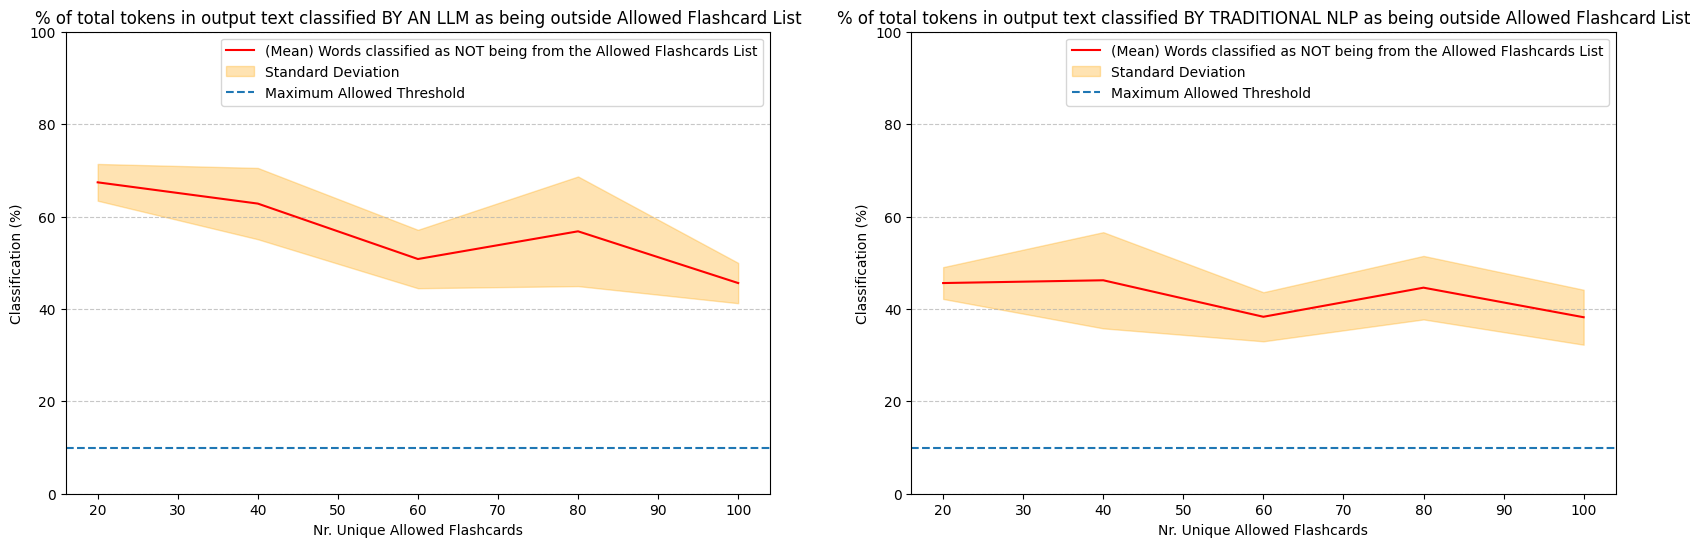

In [29]:
# Lineplot using

fig, axis = plt.subplots(1, 2, figsize=(20, 6))

axis[0].plot(
    x,
    llm_classification_means,
    label="(Mean) Words classified as NOT being from the Allowed Flashcards List",
    color="red",
)
axis[0].fill_between(
    x,
    llm_classification_means - llm_classification_stds,
    llm_classification_means + llm_classification_stds, alpha=0.3, label="Standard Deviation", color="orange")
axis[0].set_title(f"% of total tokens in output text classified BY AN LLM as being outside Allowed Flashcard List")

axis[1].plot(
    x,
    raw_checking_means,
    label="(Mean) Words classified as NOT being from the Allowed Flashcards List",
    color="red",
)
axis[1].fill_between(
    x,
    raw_checking_means - raw_checking_stds,
    raw_checking_means + raw_checking_stds,
    alpha=0.3,
    label="Standard Deviation",
    color="orange"
)
axis[1].set_title(
    f"% of total tokens in output text classified BY TRADITIONAL NLP as being outside Allowed Flashcard List"
)

for ax in axis:
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylim(0, 100)
    ax.axhline(y=10, linestyle="--", label="Maximum Allowed Threshold")
    ax.set_xlabel("Nr. Unique Allowed Flashcards")
    ax.set_ylabel("Classification (%)")
    ax.legend()

plt.show()

### Improvement Loop

Improvement loop loops between model and corrector to improve the final output to later measure the improvement and total performance in real-world tasks of this subsystem.

### Evaluation